<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dailychallenge_J5_W2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#Importation des Librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Exploration des données

data = pd.read_excel('data.xls')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [13]:
monthly_total = (
    data.groupby('Order Month-Year')['Sales']
      .sum()
)

print("Highest Sales Month:")
print(monthly_total.idxmax())
print(f"${monthly_total.max():,.0f}")

print("\nLowest Sales Month:")
print(monthly_total.idxmin())
print(f"${monthly_total.min():,.0f}")

print("\nAverage Monthly Sales:")
print(f"${monthly_total.mean():,.0f}")


Highest Sales Month:
2017-11
$118,448

Lowest Sales Month:
2014-02
$4,520

Average Monthly Sales:
$47,858


In [14]:
monthly_total.sort_values(ascending=False).head()

,Sales
Order Month-Year,
2017-11,118447.8250
2016-12,96999.0430
2017-09,87866.6520
2017-12,83829.3188
2014-09,81777.3508


### Additional Preprocessing (Feature Engineering Example)


In [23]:
# Calculate Profit Ratio
# To avoid division by zero for sales = 0, we can use np.where
data['Profit Ratio'] = np.where(data['Sales'] != 0, data['Profit'] / data['Sales'], 0)

# Display the first few rows with the new column
print('\nData with new "Profit Ratio" column:')
display(data[['Sales', 'Profit', 'Profit Ratio']].head())


Data with new "Profit Ratio" column:


,Sales,Profit,Profit Ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


## 2. Data Visualization with Matplotlib: Interactive Line Chart for Sales Trends

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from ipywidgets import interact, Dropdown

# Ensure 'Order Date' is datetime type and 'Order Month-Year' is created
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Order Month-Year'] = data['Order Date'].dt.to_period('M')

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(14,6))

    if category == 'All':
        total_monthly = data.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, marker='o', linewidth=2)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        # Filter data for the specific category and group by month-year
        category_data_filtered = data[data['Category'] == category]
        monthly_category_sales = category_data_filtered.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(monthly_category_sales.index.to_timestamp(), monthly_category_sales.values, marker='o', linewidth=2)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel("Date")
    plt.ylabel("Sales ($)")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


categories = ['All'] + list(data['Category'].unique())

interact(
    plot_monthly_sales,
    category=Dropdown(
        options=categories,
        value='All',
        description='Category'
    )
)

interactive(children=(Dropdown(description='Category', options=('All', 'Furniture', 'Office Supplies', 'Techno…

<function __main__.plot_monthly_sales(category='All')>

## Data Visualization: Interactive Map of Sales Distribution by Country

In [17]:
import plotly.express as px

# Aggregate sales by country
sales_by_country = data.groupby('Country')['Sales'].sum().reset_index()

# Create an interactive choropleth map
fig = px.choropleth(
    sales_by_country,
    locations='Country',
    locationmode='country names',
    color='Sales',
    hover_name='Country',
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Total Sales Distribution by Country'
)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## Data Visualization with Seaborn: Top 10 Products by Sales

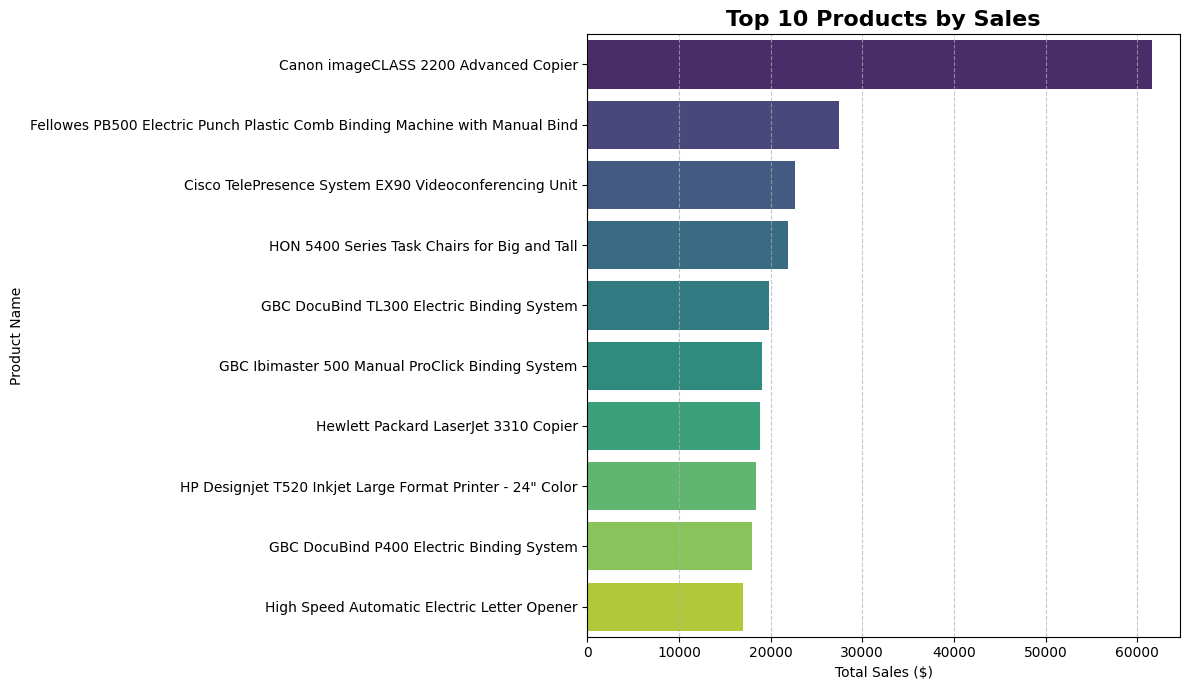

In [15]:
# Calculate top 10 products by sales
top_10_products = data.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Sales', y='Product Name', data=top_10_products, palette='viridis')
plt.title('Top 10 Products by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Data Visualization with Seaborn: Profit vs. Discount

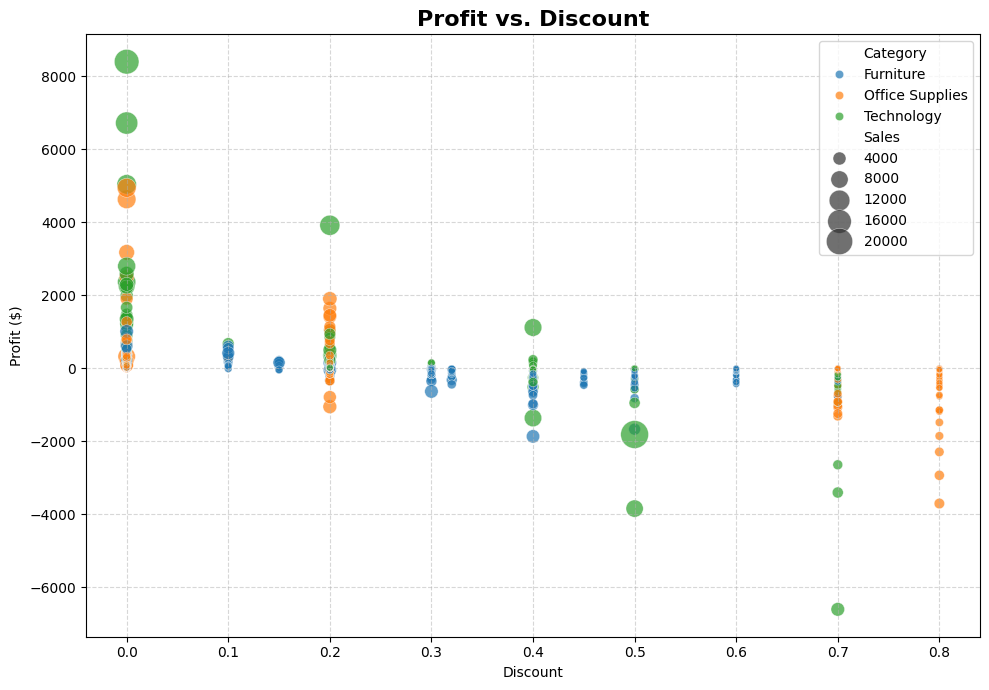

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Discount', y='Profit', data=data, hue='Category', size='Sales', sizes=(20, 400), palette='tab10', alpha=0.7)
plt.title('Profit vs. Discount', fontsize=16, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Comparative Analysis: Matplotlib vs. Seaborn

Now that we've created visualizations using both Matplotlib and Seaborn, let's compare the insights gained and document our observations about the ease of use and effectiveness of each tool.

### Insights from Matplotlib Visualizations:
*   **Interactive Line Chart (Sales Trends)**: (Add your observations here, e.g., what specific trends, seasonality, or anomalies did you notice over the years?)
*   **Interactive Map (Sales Distribution by Country)**: (Add your observations here, e.g., which countries have the highest/lowest sales? Are there any geographical patterns?)

### Insights from Seaborn Visualizations:
*   **Bar Chart (Top 10 Products by Sales)**: (Add your observations here, e.g., what types of products are top sellers? Are there any surprising entries?)
*   **Scatter Plot (Profit vs. Discount)**: (Add your observations here, e.g., what's the relationship between discount and profit? Do higher discounts always lead to lower profits? Are there specific categories that behave differently?)

### Observations on Ease of Use and Effectiveness:

*   **Matplotlib:** (Discuss your experience, e.g., flexibility, control over details, complexity for interactive plots, good for fundamental plotting.)
*   **Seaborn:** (Discuss your experience, e.g., aesthetic appeal, simplicity for statistical plots, integration with pandas, less control over fine-grained details compared to Matplotlib.)

## Code and Insights (Ongoing)

Throughout this notebook, we are also aiming to:

*   **Write clear, well-documented Python code.** (This is an ongoing effort, ensure comments and logical structure.)
*   **Include analysis and insights as comments or markdown cells.** (As you've seen, I'm adding markdown cells for explanations; please continue to add your own insights as you explore the data.)